## HSV and RGB Spaces

In [10]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
%matplotlib inline

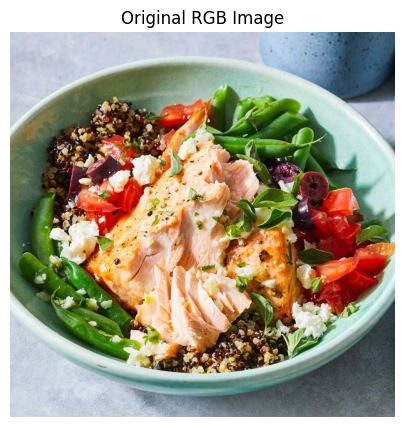

In [2]:
# 1. Load and plot an image
img = cv2.imread("image.jpeg")   
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Original RGB Image")
plt.axis("off")
plt.show()

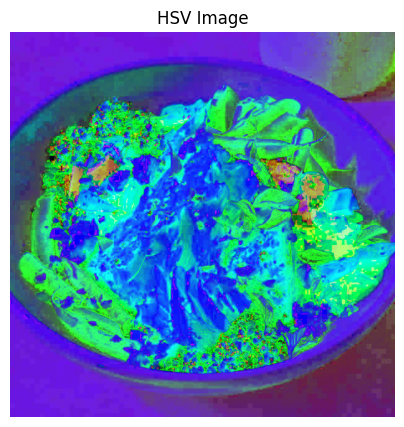

In [3]:
# 2. Convert to HSV and plot
hsv_img = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

plt.figure(figsize=(5,5))
plt.imshow(hsv_img)
plt.title("HSV Image")
plt.axis("off")
plt.show()

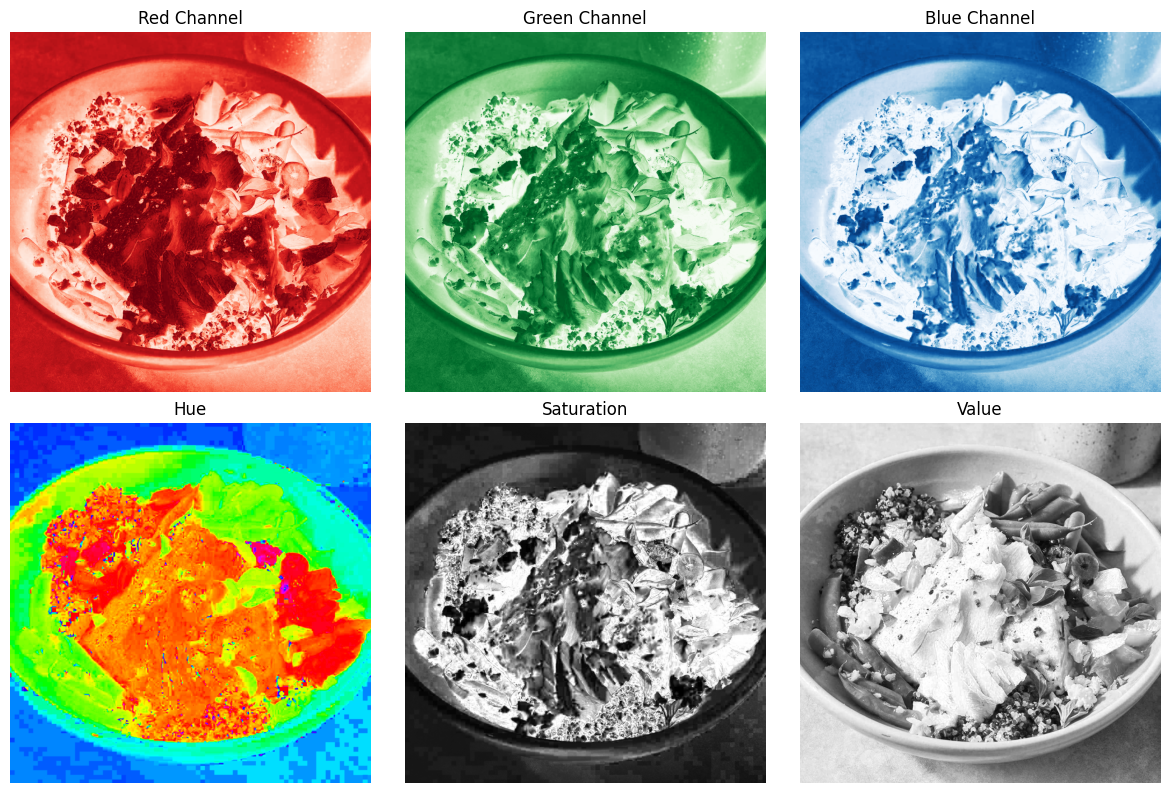

In [4]:
# 3. Isolate channels (RGB & HSV)
r, g, b = cv2.split(img)
h, s, v = cv2.split(hsv_img)

fig, axs = plt.subplots(2, 3, figsize=(12, 8))

# RGB channels (use color maps)
axs[0, 0].imshow(r, cmap="Reds")
axs[0, 0].set_title("Red Channel")
axs[0, 0].axis("off")

axs[0, 1].imshow(g, cmap="Greens")
axs[0, 1].set_title("Green Channel")
axs[0, 1].axis("off")

axs[0, 2].imshow(b, cmap="Blues")
axs[0, 2].set_title("Blue Channel")
axs[0, 2].axis("off")

# HSV channels (grayscale for S and V, scaled Hue to 0–1 for better visualization)
axs[1, 0].imshow(h / 179.0, cmap="hsv")  # Hue normalized to [0,1]
axs[1, 0].set_title("Hue")
axs[1, 0].axis("off")

axs[1, 1].imshow(s / 255.0, cmap="gray")
axs[1, 1].set_title("Saturation")
axs[1, 1].axis("off")

axs[1, 2].imshow(v / 255.0, cmap="gray")
axs[1, 2].set_title("Value")
axs[1, 2].axis("off")

plt.tight_layout()
plt.show()


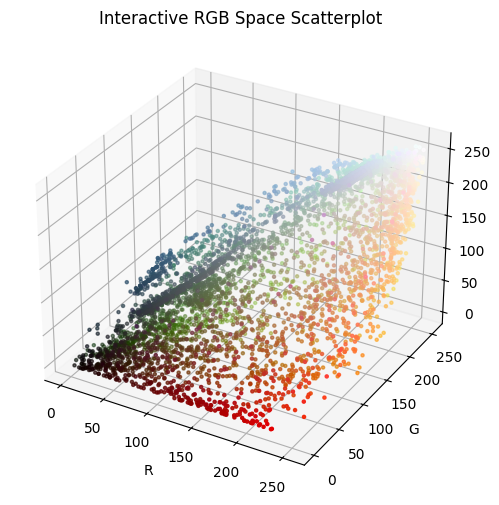

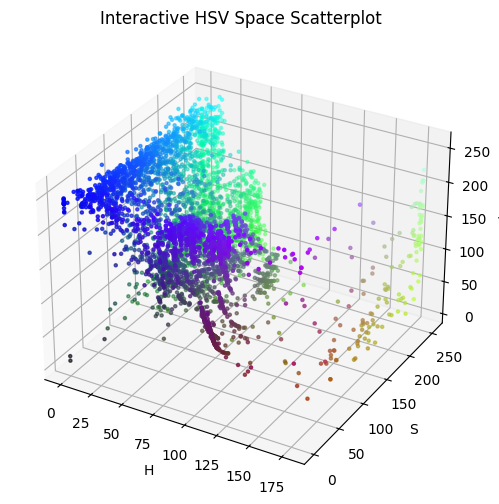

In [5]:
# 4. RGB & HSV Scatterplots

# Flatten pixels
pixels = img.reshape(-1, 3)
hsv_pixels = hsv_img.reshape(-1, 3)

# Random subsample for faster plotting
sample_idx = np.random.choice(pixels.shape[0], 5000, replace=False)
pixels_sample = pixels[sample_idx]
hsv_sample = hsv_pixels[sample_idx]

# RGB 3D scatter
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pixels_sample[:,0], pixels_sample[:,1], pixels_sample[:,2],
           c=pixels_sample/255.0, s=5)
ax.set_xlabel("R"); ax.set_ylabel("G"); ax.set_zlabel("B")
ax.set_title("Interactive RGB Space Scatterplot")
plt.show()

# HSV 3D scatter
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(hsv_sample[:,0], hsv_sample[:,1], hsv_sample[:,2],
           c=hsv_sample/255.0, s=5)
ax.set_xlabel("H"); ax.set_ylabel("S"); ax.set_zlabel("V")
ax.set_title("Interactive HSV Space Scatterplot")
plt.show()


In [6]:
# 5. Brightness Adjustment Function

def adjust_brightness(img_rgb, factor=1.0):
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype("float32")
    h, s, v = cv2.split(hsv)
    v = np.clip(v * factor, 0, 255)
    hsv_adj = cv2.merge([h, s, v])
    return cv2.cvtColor(hsv_adj.astype("uint8"), cv2.COLOR_HSV2RGB)


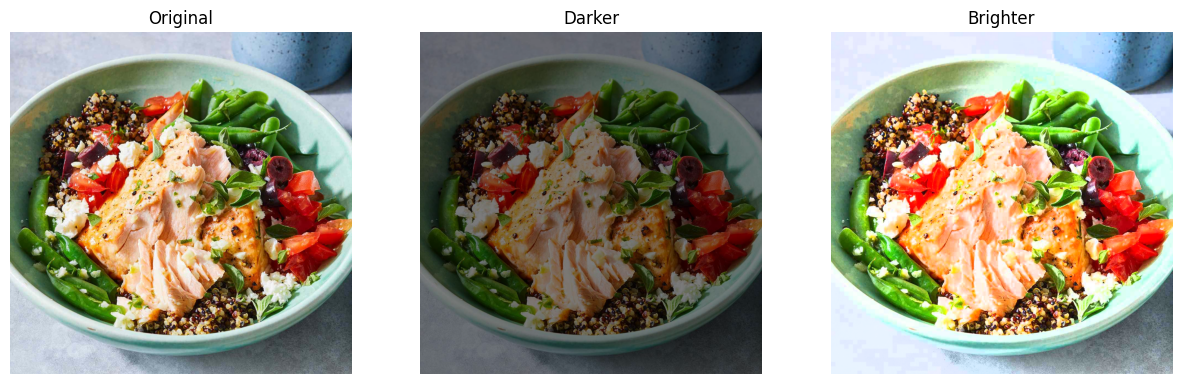

In [7]:
# 6. Darker and Brighter Images

darker = adjust_brightness(img, 0.5)
brighter = adjust_brightness(img, 1.5)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(img); axs[0].set_title("Original"); axs[0].axis("off")
axs[1].imshow(darker); axs[1].set_title("Darker"); axs[1].axis("off")
axs[2].imshow(brighter); axs[2].set_title("Brighter"); axs[2].axis("off")
plt.show()

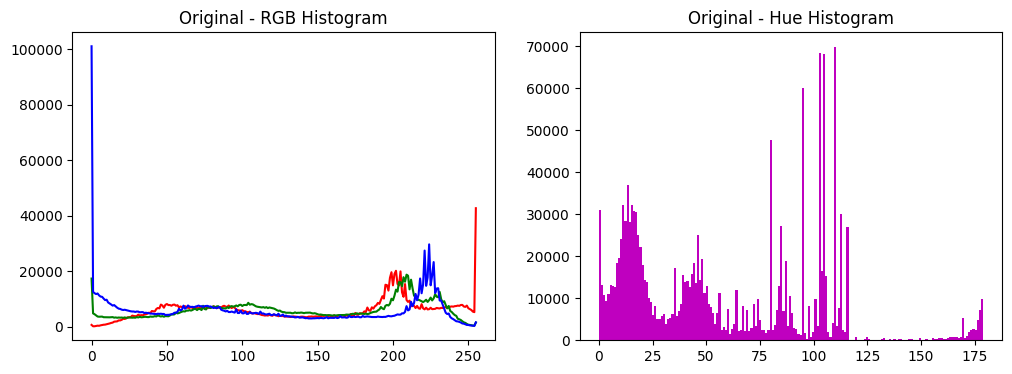

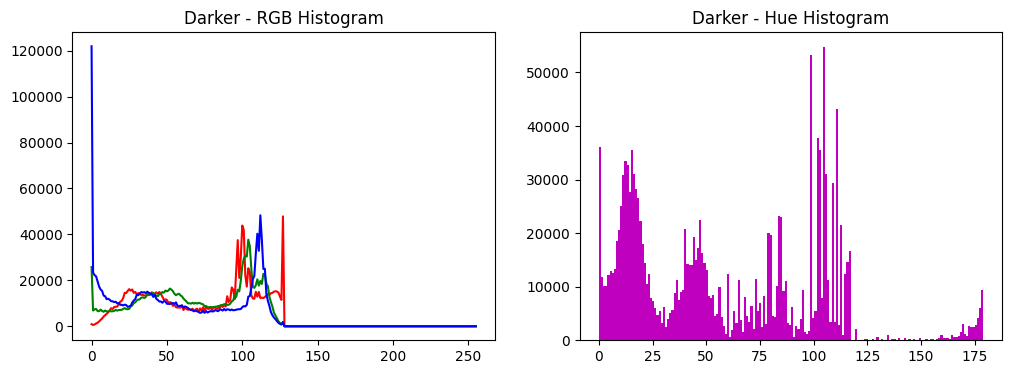

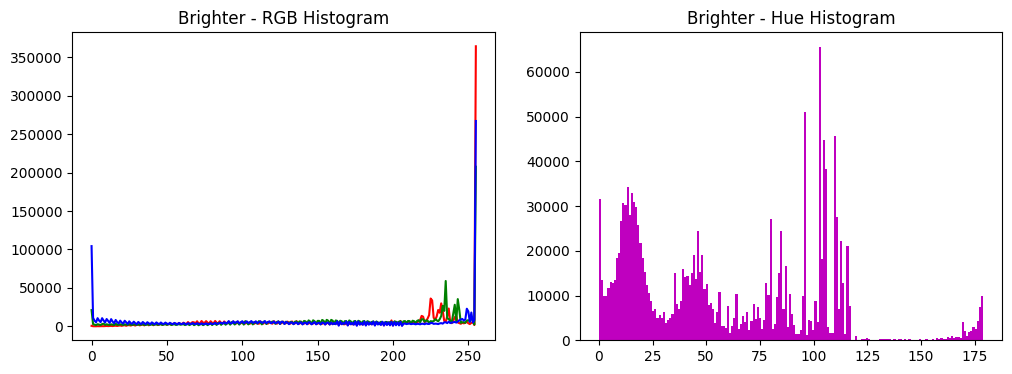

In [8]:
# 7. Histograms (RGB + Hue)

def plot_histograms(image_rgb, title="Image"):
    hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)
    
    fig, axs = plt.subplots(1, 2, figsize=(12,4))
    
    colors = ('r','g','b')
    for i, col in enumerate(colors):
        hist = cv2.calcHist([image_rgb],[i],None,[256],[0,256])
        axs[0].plot(hist, color=col)
    axs[0].set_title(f"{title} - RGB Histogram")
    
    axs[1].hist(h.ravel(), bins=180, color="m")
    axs[1].set_title(f"{title} - Hue Histogram")
    
    plt.show()

plot_histograms(img, "Original")
plot_histograms(darker, "Darker")
plot_histograms(brighter, "Brighter")

In [11]:
# 8. Feature Extraction & Clustering

os.environ["LOKY_MAX_CPU_COUNT"] = "4"  # replace 4 with your logical cores

def compute_inertia(image_rgb, space="RGB"):
    if space == "RGB":
        features = image_rgb.reshape(-1,3)
    elif space == "HSV":
        hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
        features = hsv.reshape(-1,3)
    
    kmeans = KMeans(n_clusters=1, random_state=0)
    kmeans.fit(features)
    return kmeans.inertia_

rgb_inertia = compute_inertia(brighter, "RGB")
hsv_inertia = compute_inertia(brighter, "HSV")

print("Inertia Comparison:")
print(f"RGB Space Inertia: {rgb_inertia}")
print(f"HSV Space Inertia: {hsv_inertia}")

Inertia Comparison:
RGB Space Inertia: 29714175589.53019
HSV Space Inertia: 19672332322.661373


## 8. Feature Extraction and KMeans Clustering for Compactness

To analyze the color-space compactness of an image, we extracted pixel features from both **RGB** and **HSV** spaces and applied **KMeans clustering** with `n_clusters = 1`. This allows us to check how tightly all pixels cluster together in each color space.

### Procedure

1. **Feature Extraction**  
   - Flatten the image to obtain a list of pixel vectors.  
     - RGB features: `[R, G, B]`  
     - HSV features: `[H, S, V]`

2. **Clustering**  
   - Apply `KMeans(n_clusters=1)` on both RGB and HSV features.  
   - The single cluster represents the **overall pixel distribution**.  

3. **Compactness Measurement**  
   - Use **inertia**, which is the sum of squared distances of pixels to the cluster centroid.  
   - Lower inertia → pixels are closer together → more compact distribution.

### Results

| Color Space | Inertia                |
|------------|-------------------------|
| RGB        | 29,714,175,589          |
| HSV        | 19,672,332,323          |

### Observations

- **HSV space has lower inertia** than RGB space, indicating that pixels are more compactly distributed in HSV.  
- This makes sense because HSV separates color information (H), saturation (S), and brightness (V), so similar colors cluster closer together.  

### Notes to be Considered

- **Compactness ≠ classification performance.**  
  - Lower inertia only shows tighter clustering, not better separability between different objects or classes.  
  - Two different objects can still overlap in HSV despite having lower inertia.  
  - Histograms ignore spatial information, so classification performance depends on **dataset, task, and features**, not just histogram compactness.

**Conclusion:**  
HSV features generally provide a more compact representation of pixel colors, which can be useful for color-based analysis, but it should not be interpreted as a direct measure of classifier accuracy.

## Bonus: Limitations of Using HSV Histogram Compactness as a Proxy for Classifier Performance

While HSV histograms often show **more compact distributions** than RGB histograms (lower inertia), there are important limitations to generalizing this observation for classification tasks:

### 1. Compactness ≠ Classifier Accuracy
- KMeans inertia measures **how tightly all pixels cluster around a single center**.
- Lower inertia in HSV only tells us that pixel values are more compact, but **it does not measure how well different classes are separated**.
- Two different objects can still overlap in HSV space, making classification difficult despite low inertia.

### 2. Ignoring Spatial Information
- Histograms and pixel-level clustering **ignore the spatial arrangement of pixels**.
- Many classification tasks depend on texture, edges, and object structure — features that HSV histograms cannot capture.

### 3. Dataset and Task Dependency
- The usefulness of HSV over RGB depends heavily on the dataset:
  - Images with subtle color differences may benefit from HSV.  
  - Images where brightness or shading is important may not benefit.  
- Classifier performance is determined by **the full set of features and the learning algorithm**, not just histogram compactness.

### 4. Limited Feature Representation
- HSV separates hue, saturation, and value, which helps compact similar colors, but:
  - Hue can wrap around (0 ≈ 179 in OpenCV) causing potential ambiguity.  
  - Saturation and value scaling may distort perceptual differences.
- RGB and other feature representations might still capture relevant information for certain tasks.

---

### Visualization Demonstration (Optional)

We can visualize the **overlap of pixels between two images** in HSV vs RGB to show that compactness does not guarantee separability:


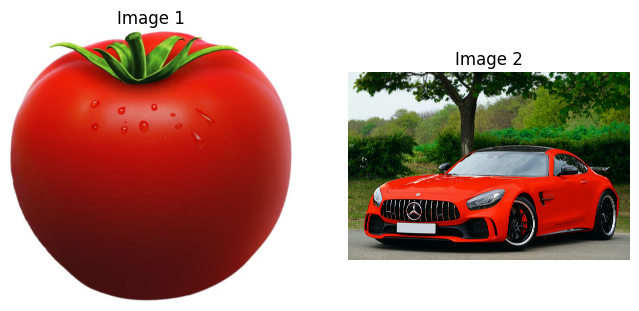

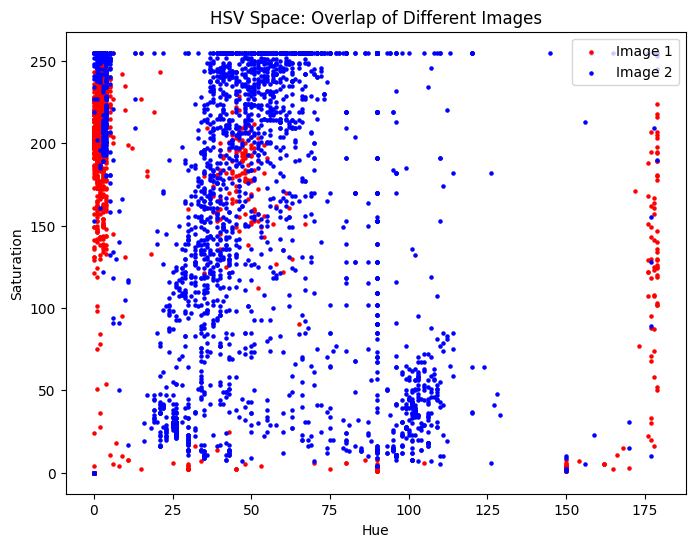

In [22]:
# Quick compare plots

img1 = cv2.imread('image1.jpg')
img2 = cv2.imread('image2.jpg')

#image plots
plt.figure(figsize=(8,6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title("Image 2")
plt.axis("off")

plt.show()

# Convert to HSV
hsv1 = cv2.cvtColor(img1, cv2.COLOR_BGR2HSV).reshape(-1,3)
hsv2 = cv2.cvtColor(img2, cv2.COLOR_BGR2HSV).reshape(-1,3)

# Sample pixels for plotting
idx1 = np.random.choice(hsv1.shape[0], 3000, replace=False)
idx2 = np.random.choice(hsv2.shape[0], 3000, replace=False)

hsv1_sample = hsv1[idx1]
hsv2_sample = hsv2[idx2]

# Plot HSV scatter
plt.figure(figsize=(8,6))
plt.scatter(hsv1_sample[:,0], hsv1_sample[:,1], c='r', s=5, label='Image 1')
plt.scatter(hsv2_sample[:,0], hsv2_sample[:,1], c='b', s=5, label='Image 2')
plt.xlabel("Hue"); plt.ylabel("Saturation")
plt.title("HSV Space: Overlap of Different Images")
plt.legend()
plt.show()

### <b>Conclusion</b>
#### <i>We can see that a large portion of the points overlap in the Hue-Saturation space, even though the images are visually different.</i>
<ul>
  <li>This confirms the limitation: HSV histogram compactness alone cannot guarantee separability for classification tasks.</li>
  <li>Hue and saturation values are similar enough between the two images to produce overlap, highlighting that compactness does not equal discriminative power.</li>
</ul>
